# Spiking Neural Network (SNN) Research Notebook
## LIF vs ALIF · Surrogate Gradient vs R-STDP · MNIST & CIFAR-10

---

### Architecture Overview

| Layer | Type | Neurons |
|-------|------|---------|
| Input (MNIST) | Encoding | 784 |
| Hidden (fc1 → lif/alif) | Spiking | **256** |
| Output (fc2 → lif/alif) | Spiking | **10** |
| **Total SNN neurons** | | **266 per model** |

> **Grand total across all 8 experiments: 2,128 SNN neurons**  
> (4 MNIST + 4 CIFAR, each with 266 spiking neurons)  
> CNN_Backbone (CIFAR only) uses convolutional feature maps — not spiking neurons.

---

**Training strategies:**
- `Surrogate Gradient` — backprop through a differentiable surrogate of the spike function
- `R-STDP` — Reward-modulated Spike-Timing Dependent Plasticity (biologically inspired)

**Neuron types:**
- `LIF` — Leaky Integrate-and-Fire (standard)
- `ALIF` — Adaptive LIF with dynamic threshold (more biologically realistic)

##  1. Installation & Setup

In [ ]:
# Install required packages
!pip install snntorch datasets --quiet
print("✅ Packages installed.")

✅ Packages installed.


##  2. Imports & Device Configuration

In [ ]:
import os
import sys
import subprocess
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import snntorch as snn
from snntorch import spikegen, surrogate
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from tqdm.notebook import tqdm
import time
import warnings
warnings.filterwarnings('ignore')

try:
    from datasets import load_dataset
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "datasets"])
    from datasets import load_dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Using device: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

🖥️  Using device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


## 3. Architecture Visualization

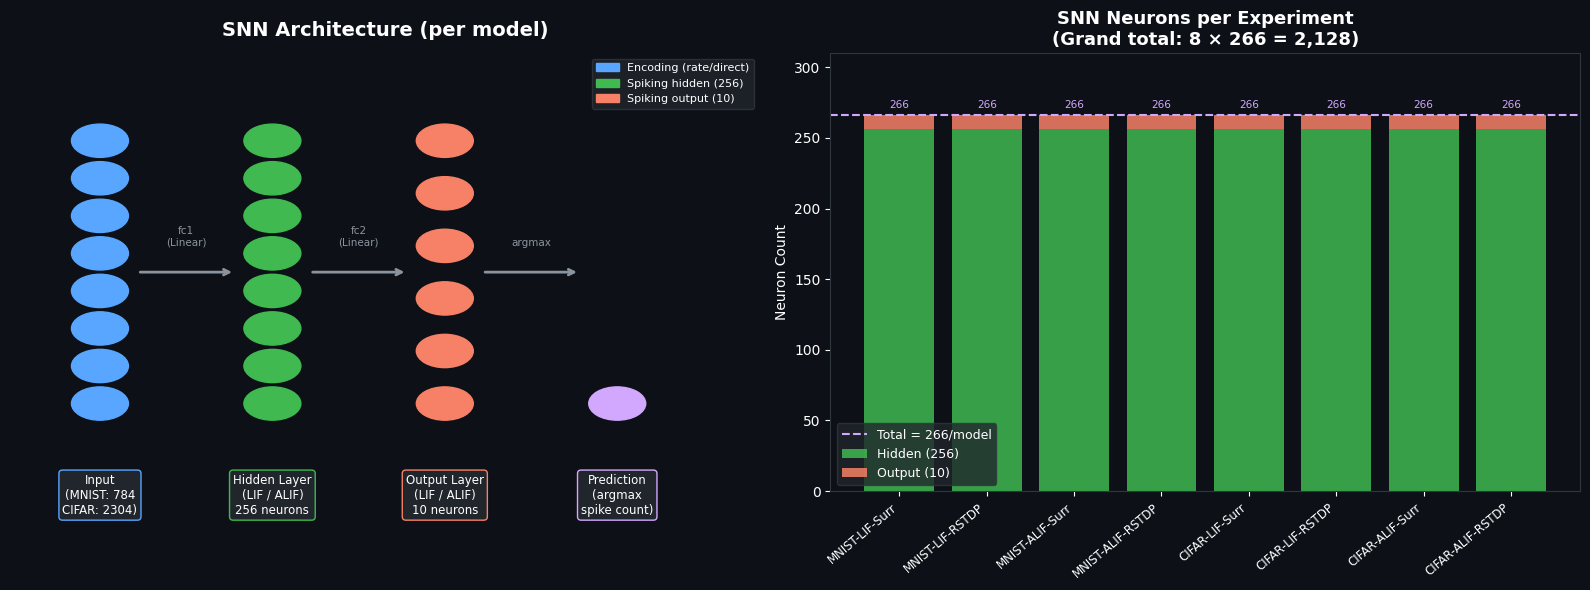

✅ Saved: architecture_overview.png


In [ ]:
# ── Research Visualization 1: Neuron count & architecture diagram ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')

# --- LEFT: Architecture schematic ---
ax1 = axes[0]
ax1.set_facecolor('#0d1117')
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis('off')
ax1.set_title('SNN Architecture (per model)', color='white', fontsize=14, fontweight='bold', pad=12)

layers = [
    {'x': 1.2, 'label': 'Input\n(MNIST: 784\nCIFAR: 2304)', 'n': 784, 'color': '#58a6ff', 'type': 'encoding'},
    {'x': 3.5, 'label': 'Hidden Layer\n(LIF / ALIF)\n256 neurons', 'n': 256, 'color': '#3fb950', 'type': 'spiking'},
    {'x': 5.8, 'label': 'Output Layer\n(LIF / ALIF)\n10 neurons', 'n': 10, 'color': '#f78166', 'type': 'spiking'},
    {'x': 8.1, 'label': 'Prediction\n(argmax\nspike count)', 'n': 1, 'color': '#d2a8ff', 'type': 'output'},
]

node_r = 0.38
def draw_nodes(ax, x, n_display, color, alpha=1.0):
    centers = np.linspace(2.0, 8.0, min(n_display, 8))
    for y in centers:
        circle = plt.Circle((x, y), node_r, color=color, alpha=alpha, zorder=3)
        ax.add_patch(circle)
    if n_display > 8:
        ax.text(x, 1.2, f'... ({n_display})', color=color, ha='center', fontsize=8, va='top')

node_counts = [8, 8, 6, 1]
for i, layer in enumerate(layers):
    draw_nodes(ax1, layer['x'], node_counts[i], layer['color'])
    ax1.text(layer['x'], 0.4, layer['label'], color='white', ha='center', fontsize=8.5,
             va='top', multialignment='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#21262d', edgecolor=layer['color'], linewidth=1))

# Draw arrows between layers
for i in range(len(layers) - 1):
    ax1.annotate('', xy=(layers[i+1]['x'] - 0.5, 5), xytext=(layers[i]['x'] + 0.5, 5),
                 arrowprops=dict(arrowstyle='->', color='#8b949e', lw=2))
    label = 'fc1\n(Linear)' if i == 0 else ('fc2\n(Linear)' if i == 1 else 'argmax')
    ax1.text((layers[i]['x'] + layers[i+1]['x']) / 2, 5.6, label,
             color='#8b949e', ha='center', fontsize=7.5)

# Legend
patches = [
    mpatches.Patch(color='#58a6ff', label='Encoding (rate/direct)'),
    mpatches.Patch(color='#3fb950', label='Spiking hidden (256)'),
    mpatches.Patch(color='#f78166', label='Spiking output (10)'),
]
ax1.legend(handles=patches, loc='upper right', facecolor='#21262d',
           edgecolor='#30363d', labelcolor='white', fontsize=8)

# --- RIGHT: Neuron count bar chart ---
ax2 = axes[1]
ax2.set_facecolor('#0d1117')
experiments = ['MNIST-LIF-Surr', 'MNIST-LIF-RSTDP', 'MNIST-ALIF-Surr', 'MNIST-ALIF-RSTDP',
               'CIFAR-LIF-Surr', 'CIFAR-LIF-RSTDP', 'CIFAR-ALIF-Surr', 'CIFAR-ALIF-RSTDP']
hidden = [256] * 8
output = [10] * 8
x = np.arange(len(experiments))

bars1 = ax2.bar(x, hidden, label='Hidden (256)', color='#3fb950', alpha=0.85)
bars2 = ax2.bar(x, output, bottom=hidden, label='Output (10)', color='#f78166', alpha=0.85)
ax2.axhline(266, color='#d2a8ff', linestyle='--', lw=1.5, label='Total = 266/model')
ax2.set_xticks(x)
ax2.set_xticklabels(experiments, rotation=40, ha='right', fontsize=8.5, color='white')
ax2.set_ylabel('Neuron Count', color='white')
ax2.set_title('SNN Neurons per Experiment\n(Grand total: 8 × 266 = 2,128)', color='white', fontsize=13, fontweight='bold')
ax2.tick_params(colors='white')
ax2.spines[:].set_color('#30363d')
ax2.set_facecolor('#0d1117')
ax2.legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='white', fontsize=9)
ax2.set_ylim(0, 310)
# Annotate total
for bar, h in zip(bars2, output):
    ax2.text(bar.get_x() + bar.get_width()/2, 266 + 5, '266', ha='center', color='#d2a8ff', fontsize=7.5)

plt.tight_layout()
plt.savefig('architecture_overview.png', dpi=200, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Saved: architecture_overview.png")

### 3.2 Membrane Potential Dynamics: LIF vs ALIF

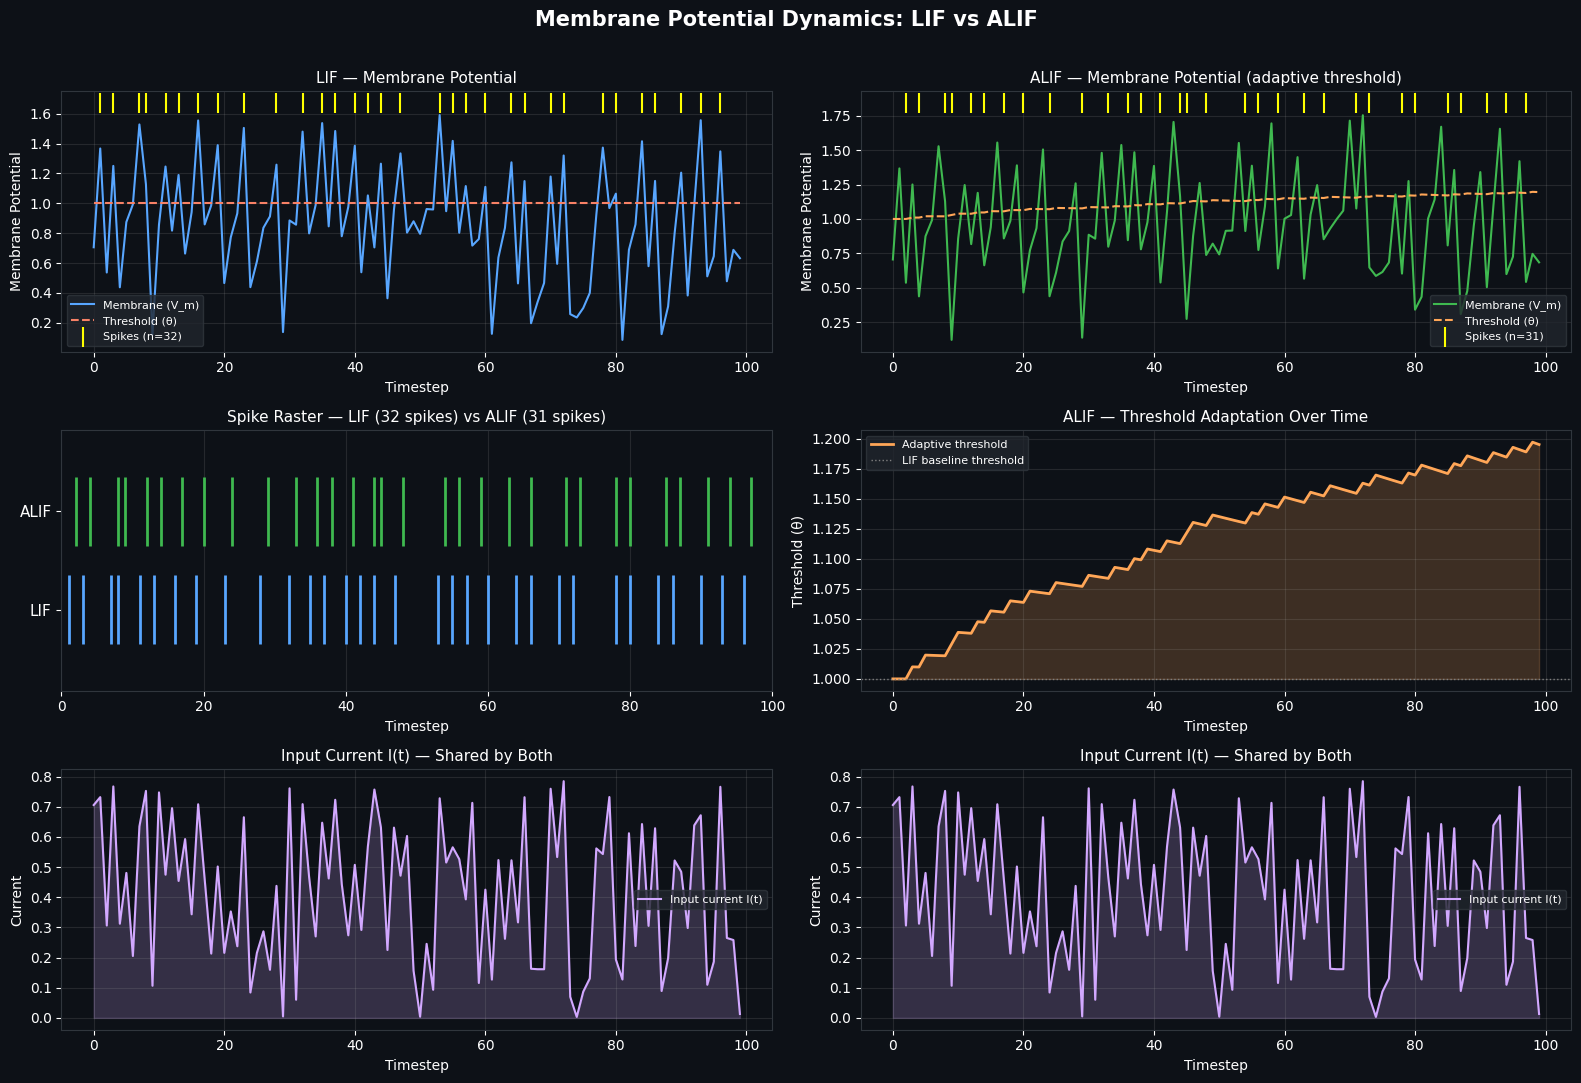

✅ Saved: membrane_dynamics.png


In [ ]:
# ── Research Visualization 2: LIF vs ALIF membrane dynamics ──
T = 100  # timesteps
beta = 0.9
torch.manual_seed(42)
inp = torch.rand(T) * 0.8  # random input current

# --- Simulate LIF ---
mem_lif, spk_lif, threshold_lif = [], [], []
mem = torch.tensor(0.0)
lif_neuron = snn.Leaky(beta=beta)
mem_state = lif_neuron.init_leaky()
for t in range(T):
    spk, mem_state = lif_neuron(inp[t].unsqueeze(0), mem_state)
    mem_lif.append(mem_state.item())
    spk_lif.append(spk.item())
    threshold_lif.append(1.0)

# --- Simulate ALIF ---
mem_alif, spk_alif, threshold_alif, adapt_vals = [], [], [], []
spike_fn = surrogate.fast_sigmoid(slope=25)
mem_a = torch.tensor(0.0)
adapt = torch.tensor(0.0)
for t in range(T):
    thr = 1.0 + adapt.item()
    spk = spike_fn(mem_a - thr)
    adapt = 0.99 * adapt + 0.01 * spk
    mem_a = beta * mem_a + inp[t] - spk
    mem_alif.append(mem_a.item())
    spk_alif.append(spk.item())
    threshold_alif.append(thr)
    adapt_vals.append(adapt.item())

# --- Plot ---
fig, axes = plt.subplots(3, 2, figsize=(16, 11), facecolor='#0d1117')
fig.suptitle('Membrane Potential Dynamics: LIF vs ALIF', color='white', fontsize=15, fontweight='bold', y=0.98)
t_axis = np.arange(T)

pairs = [
    (axes[0, 0], mem_lif, threshold_lif, spk_lif, 'LIF — Membrane Potential', '#58a6ff', '#f78166'),
    (axes[0, 1], mem_alif, threshold_alif, spk_alif, 'ALIF — Membrane Potential (adaptive threshold)', '#3fb950', '#ffa657'),
]
for ax, mem, thr, spk, title, mcol, tcol in pairs:
    ax.set_facecolor('#0d1117')
    ax.plot(t_axis, mem, color=mcol, lw=1.5, label='Membrane (V_m)')
    ax.plot(t_axis, thr, color=tcol, lw=1.5, linestyle='--', label='Threshold (θ)')
    spk_times = [t for t, s in enumerate(spk) if s > 0.5]
    ax.scatter(spk_times, [max(mem) * 1.05] * len(spk_times), marker='|', s=200,
               color='yellow', zorder=5, label=f'Spikes (n={len(spk_times)})')
    ax.set_title(title, color='white', fontsize=11)
    ax.set_xlabel('Timestep', color='white')
    ax.set_ylabel('Membrane Potential', color='white')
    ax.tick_params(colors='white')
    ax.spines[:].set_color('#30363d')
    ax.legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='white', fontsize=8)
    ax.grid(True, alpha=0.15)

# ALIF threshold adaptation
ax3 = axes[1, 1]
ax3.set_facecolor('#0d1117')
ax3.plot(t_axis, threshold_alif, color='#ffa657', lw=2, label='Adaptive threshold')
ax3.fill_between(t_axis, 1.0, threshold_alif, alpha=0.2, color='#ffa657')
ax3.axhline(1.0, color='gray', linestyle=':', lw=1, label='LIF baseline threshold')
ax3.set_title('ALIF — Threshold Adaptation Over Time', color='white', fontsize=11)
ax3.set_xlabel('Timestep', color='white')
ax3.set_ylabel('Threshold (θ)', color='white')
ax3.tick_params(colors='white')
ax3.spines[:].set_color('#30363d')
ax3.legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='white', fontsize=8)
ax3.grid(True, alpha=0.15)

# Spike raster comparison
ax4 = axes[1, 0]
ax4.set_facecolor('#0d1117')
lif_spk_t  = [t for t, s in enumerate(spk_lif)  if s > 0.5]
alif_spk_t = [t for t, s in enumerate(spk_alif) if s > 0.5]
ax4.eventplot([lif_spk_t, alif_spk_t], colors=['#58a6ff', '#3fb950'],
              lineoffsets=[1, 2], linelengths=0.7, linewidths=2)
ax4.set_yticks([1, 2])
ax4.set_yticklabels(['LIF', 'ALIF'], color='white', fontsize=11)
ax4.set_xlabel('Timestep', color='white')
ax4.set_title(f'Spike Raster — LIF ({len(lif_spk_t)} spikes) vs ALIF ({len(alif_spk_t)} spikes)',
              color='white', fontsize=11)
ax4.tick_params(colors='white')
ax4.spines[:].set_color('#30363d')
ax4.grid(True, alpha=0.15, axis='x')
ax4.set_xlim(0, T)

# Input current
for col, ax in enumerate([axes[2, 0], axes[2, 1]]):
    ax.set_facecolor('#0d1117')
    ax.plot(t_axis, inp.numpy(), color='#d2a8ff', lw=1.5, label='Input current I(t)')
    ax.fill_between(t_axis, 0, inp.numpy(), alpha=0.2, color='#d2a8ff')
    ax.set_title('Input Current I(t) — Shared by Both', color='white', fontsize=11)
    ax.set_xlabel('Timestep', color='white')
    ax.set_ylabel('Current', color='white')
    ax.tick_params(colors='white')
    ax.spines[:].set_color('#30363d')
    ax.legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='white', fontsize=8)
    ax.grid(True, alpha=0.15)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('membrane_dynamics.png', dpi=200, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Saved: membrane_dynamics.png")

### 3.3 Spike Encoding Visualization: Poisson vs Direct

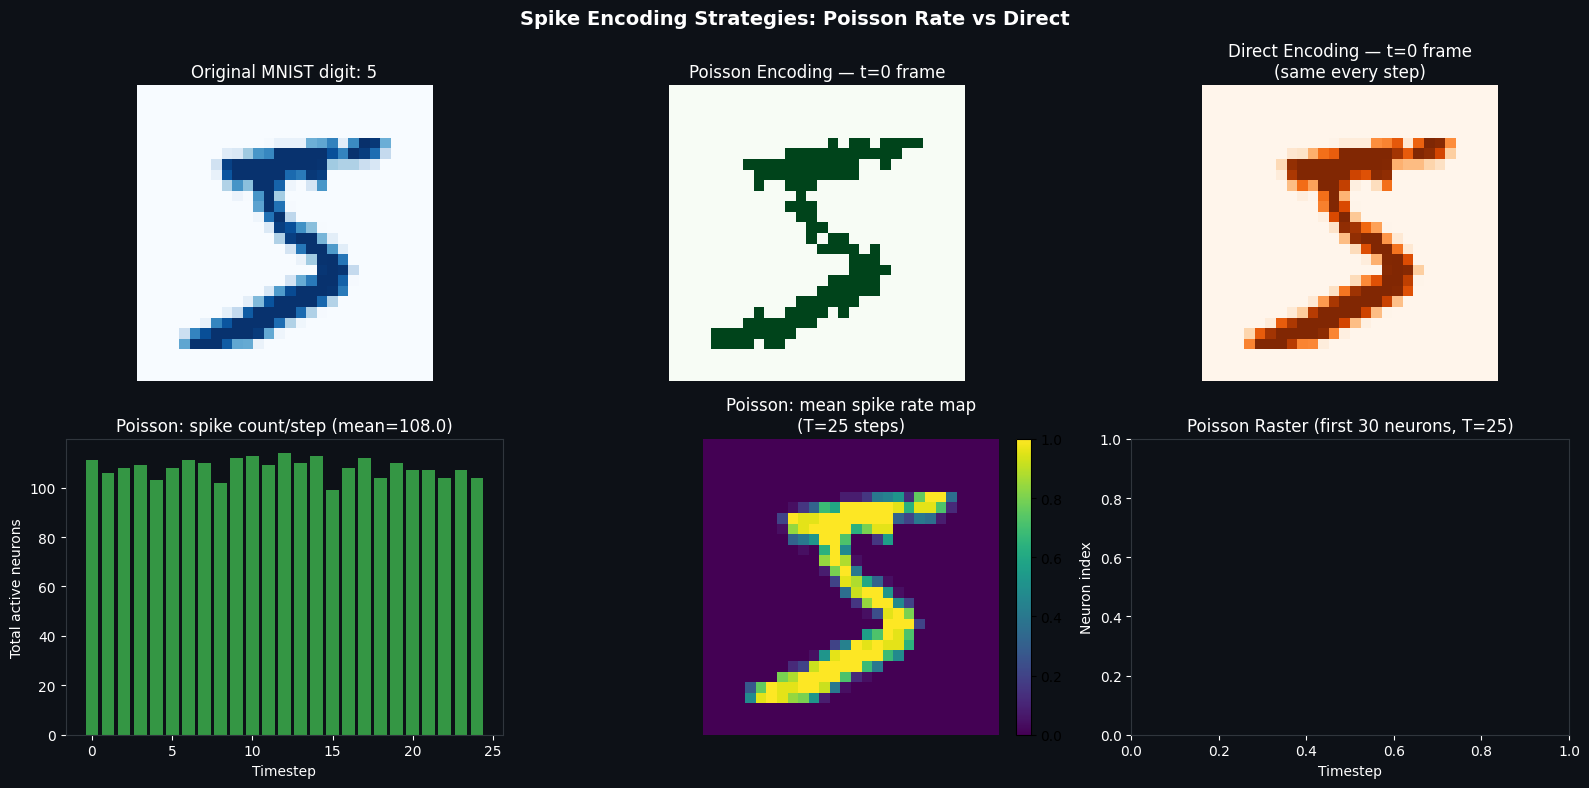

✅ Saved: encoding_visualization.png


In [ ]:
transform = transforms.ToTensor()
mnist_sample = torchvision.datasets.MNIST('./data', train=True, download=True, transform=transform)
img, label = mnist_sample[0]
img_flat = img.view(-1)  # [784]
T_enc = 25  # encoding timesteps
torch.manual_seed(0)

poisson_enc = spikegen.rate(img_flat.unsqueeze(0), num_steps=T_enc)  # [T, 1, 784]
direct_enc = img_flat.unsqueeze(0).unsqueeze(0).repeat(T_enc, 1, 1)  # [T, 1, 784]

fig, axes = plt.subplots(2, 3, figsize=(16, 8), facecolor='#0d1117')
fig.suptitle('Spike Encoding Strategies: Poisson Rate vs Direct', color='white',
             fontsize=14, fontweight='bold')

# Original image
axes[0, 0].imshow(img.squeeze(), cmap='Blues', interpolation='nearest')
axes[0, 0].set_title(f'Original MNIST digit: {label}', color='white')
axes[0, 0].axis('off')

# Poisson single frame
axes[0, 1].imshow(poisson_enc[0, 0].view(28, 28).numpy(), cmap='Greens', vmin=0, vmax=1)
axes[0, 1].set_title('Poisson Encoding — t=0 frame', color='white')
axes[0, 1].axis('off')

# Direct single frame
axes[0, 2].imshow(direct_enc[0, 0].view(28, 28).numpy(), cmap='Oranges', vmin=0, vmax=1)
axes[0, 2].set_title('Direct Encoding — t=0 frame\n(same every step)', color='white')
axes[0, 2].axis('off')

# Spike count over time for poisson
poisson_counts = poisson_enc[:, 0, :].sum(1).numpy()  # spikes per timestep
direct_counts  = direct_enc[:, 0, :].sum(1).numpy()

axes[1, 0].bar(range(T_enc), poisson_counts, color='#3fb950', alpha=0.8)
axes[1, 0].set_facecolor('#0d1117')
axes[1, 0].set_xlabel('Timestep', color='white')
axes[1, 0].set_ylabel('Total active neurons', color='white')
axes[1, 0].set_title(f'Poisson: spike count/step (mean={poisson_counts.mean():.1f})', color='white')
axes[1, 0].tick_params(colors='white')
axes[1, 0].spines[:].set_color('#30363d')

# Pixel-wise spike rate (poisson)
spike_rate_map = poisson_enc[:, 0, :].mean(0).view(28, 28).numpy()
im = axes[1, 1].imshow(spike_rate_map, cmap='viridis', vmin=0, vmax=1)
axes[1, 1].set_title(f'Poisson: mean spike rate map\n(T={T_enc} steps)', color='white')
axes[1, 1].axis('off')
plt.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04)

# Raster plot for 30 neurons over time
raster_neurons = 30
pois_raster = poisson_enc[:, 0, :raster_neurons].numpy()
spk_times_pois = [np.where(pois_raster[:, n] > 0)[0].tolist() for n in range(raster_neurons)]
axes[1, 2].eventplot(spk_times_pois, orientation='horizontal',
                     colors=['#3fb950'] * raster_neurons, linewidths=1.5)
axes[1, 2].set_facecolor('#0d1117')
axes[1, 2].set_xlabel('Timestep', color='white')
axes[1, 2].set_ylabel('Neuron index', color='white')
axes[1, 2].set_title(f'Poisson Raster (first {raster_neurons} neurons, T={T_enc})', color='white')
axes[1, 2].tick_params(colors='white')
axes[1, 2].spines[:].set_color('#30363d')

for ax in axes.flat:
    ax.set_facecolor('#0d1117')

plt.tight_layout()
plt.savefig('encoding_visualization.png', dpi=200, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Saved: encoding_visualization.png")

##  4. Dataset Loading

In [ ]:
transform = transforms.ToTensor()

def get_dataset_loader(dataset_cls, root, train, transform, batch_size=128, download=True):
    try:
        dataset = dataset_cls(root, train=train, download=download, transform=transform)
    except Exception as exc:
        print(f"Warning: failed to load {dataset_cls.__name__}: {exc}")
        try:
            dataset = dataset_cls(root, train=train, download=False, transform=transform)
        except Exception as exc2:
            print(f"Unable to load {dataset_cls.__name__}: {exc2}")
            return None
    return torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

class HFCIFARDataset(torch.utils.data.Dataset):
    def __init__(self, split='train', transform=None):
        self.dataset = load_dataset('cifar10', split=split)
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        image = item['img']
        label = item['label']
        if self.transform:
            image = self.transform(image)
        return image, label

def get_cifar_from_hf(batch_size=128, split='train'):
    try:
        dataset = HFCIFARDataset(split=split, transform=transform)
        return torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    except Exception as exc:
        print(f"Warning: CIFAR10 from HuggingFace failed: {exc}")
        return None

mnist_loader = get_dataset_loader(torchvision.datasets.MNIST, './data', train=True, transform=transform)
cifar_loader = get_cifar_from_hf(batch_size=128, split='train')
print(f"✅ MNIST loader: {mnist_loader is not None}")
print(f"✅ CIFAR loader: {cifar_loader is not None}")

✅ MNIST loader: True
✅ CIFAR loader: True


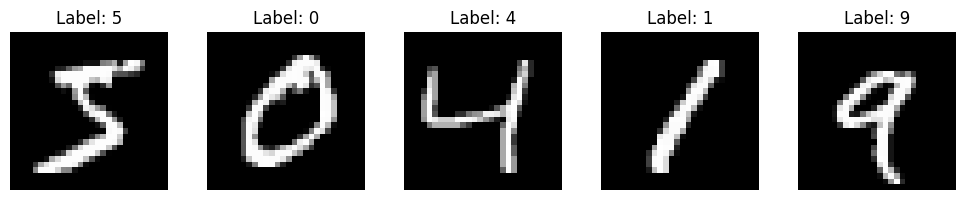

In [ ]:
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms

# Transform
transform = transforms.Compose([transforms.ToTensor()])

# Load MNIST dataset
mnist_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Get sample images
fig, axes = plt.subplots(1, 5, figsize=(10, 2))

for i in range(5):
    image, label = mnist_dataset[i]
    axes[i].imshow(image.squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

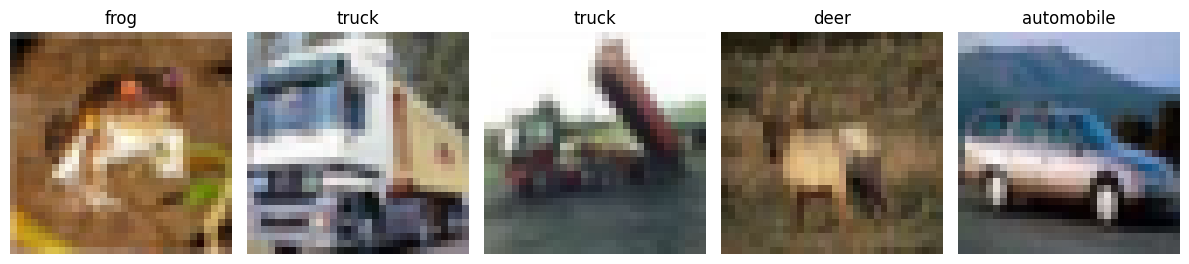

In [ ]:
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# Transform
transform = transforms.Compose([transforms.ToTensor()])

# Load CIFAR-10 dataset
cifar_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

# Class names
classes = cifar_dataset.classes

# Plot images
fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i in range(5):
    image, label = cifar_dataset[i]
    image = image.permute(1, 2, 0)  # Convert (C,H,W) → (H,W,C)

    axes[i].imshow(image)
    axes[i].set_title(classes[label])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

##  5. Spike Encoding Functions

In [ ]:
def poisson_encode(x, steps=25):
    """Rate coding: pixel value → Poisson spike probability over T steps."""
    return spikegen.rate(x, num_steps=int(steps))

def direct_encode(x, steps=25):
    """Direct coding: replicate the continuous value at every timestep."""
    x = x.unsqueeze(0)
    repeat_dims = [steps] + [1] * (x.ndim - 1)
    return x.repeat(*repeat_dims)

print("✅ Encoding functions defined.")

✅ Encoding functions defined.


##  6. Spiking Neuron Models
### 6.1 LIF and ALIF definitions

In [ ]:
class SNN_LIF(nn.Module):
    """2-layer Leaky Integrate-and-Fire SNN.
    Neurons: 256 (hidden) + 10 (output) = 266 total.
    """
    def __init__(self, input_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 256)
        self.lif1 = snn.Leaky(beta=0.9)
        self.fc2 = nn.Linear(256, 10)
        self.lif2 = snn.Leaky(beta=0.9)

    def forward(self, x, return_intermediate=False):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        spk2_rec, spk1_rec = [], []
        for t in range(x.size(0)):
            cur1 = self.fc1(x[t])
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2_rec.append(spk2)
            spk1_rec.append(spk1)
        spk2_out = torch.stack(spk2_rec)
        if return_intermediate:
            return spk2_out, torch.stack(spk1_rec)
        return spk2_out


class ALIFLayer(nn.Module):
    """Adaptive LIF with dynamic threshold (biologically realistic)."""
    def __init__(self, size):
        super().__init__()
        self.beta = 0.9
        self.spike_fn = surrogate.fast_sigmoid(slope=25)

    def forward(self, input, mem, adapt):
        threshold = 1.0 + adapt
        spk = self.spike_fn(mem - threshold)
        adapt = 0.99 * adapt + 0.01 * spk
        mem = self.beta * mem + input - spk
        return spk, mem, adapt


class SNN_ALIF(nn.Module):
    """2-layer Adaptive LIF SNN.
    Neurons: 256 (hidden) + 10 (output) = 266 total.
    """
    def __init__(self, input_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 256)
        self.alif1 = ALIFLayer(256)
        self.fc2 = nn.Linear(256, 10)
        self.alif2 = ALIFLayer(10)

    def forward(self, x, return_intermediate=False):
        batch = x.size(1)
        mem1 = torch.zeros(batch, 256).to(device)
        mem2 = torch.zeros(batch, 10).to(device)
        adapt1 = torch.zeros_like(mem1)
        adapt2 = torch.zeros_like(mem2)
        spk2_rec, spk1_rec = [], []
        for t in range(x.size(0)):
            cur1 = self.fc1(x[t])
            spk1, mem1, adapt1 = self.alif1(cur1, mem1, adapt1)
            cur2 = self.fc2(spk1)
            spk2, mem2, adapt2 = self.alif2(cur2, mem2, adapt2)
            spk2_rec.append(spk2)
            spk1_rec.append(spk1)
        spk2_out = torch.stack(spk2_rec)
        if return_intermediate:
            return spk2_out, torch.stack(spk1_rec)
        return spk2_out


class CNN_Backbone(nn.Module):
    """CNN feature extractor for CIFAR-10 (non-spiking, outputs flat features)."""
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1), nn.ReLU(), nn.MaxPool2d(2)
        )

    def forward(self, x):
        return self.conv(x).view(x.size(0), -1)

print("✅ SNN_LIF, SNN_ALIF, CNN_Backbone defined.")
print(f"   SNN_LIF  (MNIST): {sum(p.numel() for p in SNN_LIF(784).parameters()):,} parameters")
print(f"   SNN_ALIF (MNIST): {sum(p.numel() for p in SNN_ALIF(784).parameters()):,} parameters")
print(f"   CNN_Backbone:     {sum(p.numel() for p in CNN_Backbone().parameters()):,} parameters")

✅ SNN_LIF, SNN_ALIF, CNN_Backbone defined.
   SNN_LIF  (MNIST): 203,530 parameters
   SNN_ALIF (MNIST): 203,530 parameters
   CNN_Backbone:     19,392 parameters


##  7. Training: Surrogate Gradient & R-STDP

In [ ]:
def train_surrogate(model, loader, encoding, epochs=15, backbone=None):
    params = list(model.parameters())
    if backbone is not None:
        backbone.train()
        params += list(backbone.parameters())
    optimizer = optim.Adam(params, lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    acc_list, loss_list, time_list = [], [], []
    for ep in range(epochs):
        start = time.time()
        correct, total, running_loss = 0, 0, 0.0
        for data, targets in tqdm(loader, desc=f"Surrogate Epoch {ep+1}/{epochs}", leave=False):
            data, targets = data.to(device), targets.to(device)
            if backbone:
                data = backbone(data)
            spk = poisson_encode(data) if encoding == "poisson" else direct_encode(data)
            spk = spk.view(spk.size(0), spk.size(1), -1)
            out = model(spk).sum(0)
            loss = loss_fn(out, targets)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            _, pred = out.max(1)
            total += targets.size(0)
            correct += pred.eq(targets).sum().item()
            running_loss += loss.item() * targets.size(0)
        acc = 100 * correct / total if total > 0 else 0.0
        avg_loss = running_loss / total if total > 0 else 0.0
        acc_list.append(acc)
        loss_list.append(avg_loss)
        time_list.append(time.time() - start)
        print(f"  Epoch {ep+1}: acc={acc:.2f}%, loss={avg_loss:.4f}, time={time_list[-1]:.1f}s")
    return acc_list, loss_list, time_list


def rstdp_update(weights, pre, post, reward, lr=1e-4):
    """Reward-modulated STDP: Δw ∝ reward × post × pre."""
    reward = reward.unsqueeze(1).unsqueeze(2)
    post_r = post.unsqueeze(2)
    pre_r  = pre.unsqueeze(1)
    dw = (reward * post_r * pre_r).mean(0)
    dw = dw / (dw.abs().max() + 1e-8)
    weights += lr * dw
    weights.clamp_(-2.0, 2.0)
    return weights


def train_rstdp(model, loader, encoding, epochs=5, backbone=None):
    acc_list, time_list = [], []
    for ep in range(epochs):
        start = time.time()
        correct, total = 0, 0
        for data, targets in tqdm(loader, desc=f"R-STDP Epoch {ep+1}/{epochs}", leave=False):
            data, targets = data.to(device), targets.to(device)
            if backbone:
                with torch.no_grad():
                    data = backbone(data)
            spk = poisson_encode(data) if encoding == "poisson" else direct_encode(data)
            spk = spk.view(spk.size(0), spk.size(1), -1)
            with torch.no_grad():
                out, spk1 = model(spk, return_intermediate=True)
            out_sum  = out.sum(0)
            spk1_rate = spk1.mean(0)
            out_rate  = out.mean(0)
            _, pred = out_sum.max(1)
            reward = (pred == targets).float() * 2 - 1
            for pname, param in model.named_parameters():
                if "fc2.weight" in pname:
                    param.data = rstdp_update(param.data, pre=spk1_rate.detach(),
                                              post=out_rate.detach(), reward=reward.detach())
            total += targets.size(0)
            correct += pred.eq(targets).sum().item()
        acc = 100 * correct / total if total > 0 else 0.0
        acc_list.append(acc)
        time_list.append(time.time() - start)
        print(f"  R-STDP Epoch {ep+1}: acc={acc:.2f}%, time={time_list[-1]:.1f}s")
    return acc_list, time_list

print("✅ Training functions defined.")

✅ Training functions defined.


## 8. Evaluation Utilities

In [ ]:
def evaluate_model(model, loader, encoding, backbone=None):
    model.eval()
    if backbone is not None:
        backbone.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for data, targets in loader:
            data, targets = data.to(device), targets.to(device)
            if backbone:
                data = backbone(data)
            spk = poisson_encode(data) if encoding == "poisson" else direct_encode(data)
            spk = spk.view(spk.size(0), spk.size(1), -1)
            out = model(spk).sum(0)
            _, pred = out.max(1)
            total += targets.size(0)
            correct += pred.eq(targets).sum().item()
    model.train()
    if backbone is not None:
        backbone.train()
    return 100 * correct / total if total > 0 else 0.0


def build_confusion_matrix(model, loader, encoding, backbone=None, num_classes=10):
    model.eval()
    cm = torch.zeros(num_classes, num_classes, dtype=torch.int64)
    with torch.no_grad():
        for data, targets in loader:
            data, targets = data.to(device), targets.to(device)
            if backbone:
                data = backbone(data)
            spk = poisson_encode(data) if encoding == "poisson" else direct_encode(data)
            spk = spk.view(spk.size(0), spk.size(1), -1)
            out = model(spk).sum(0)
            _, pred = out.max(1)
            for t, p in zip(targets.view(-1), pred.view(-1)):
                cm[t, p] += 1
    model.train()
    return cm.cpu().numpy()

print("✅ Evaluation utilities defined.")

✅ Evaluation utilities defined.


## 9. Run All Experiments

In [ ]:
results = {}
os.makedirs('experiment_results', exist_ok=True)

if mnist_loader is None:
    print("ERROR: MNIST loader unavailable. Cannot run experiments.")
else:
    mnist_test = get_dataset_loader(torchvision.datasets.MNIST, './data', train=False,
                                    transform=transform, batch_size=128, download=False)
    cifar_test = get_cifar_from_hf(batch_size=128, split='test') if cifar_loader else None

    experiments = [
        ("MNIST-LIF-Surr",  SNN_LIF(784),  "Surrogate", "MNIST", "poisson", mnist_loader, mnist_test, None),
        ("MNIST-ALIF-Surr", SNN_ALIF(784), "Surrogate", "MNIST", "poisson", mnist_loader, mnist_test, None),
        ("MNIST-LIF-RSTDP", SNN_LIF(784),  "R-STDP",    "MNIST", "poisson", mnist_loader, mnist_test, None),
        ("MNIST-ALIF-RSTDP",SNN_ALIF(784), "R-STDP",    "MNIST", "poisson", mnist_loader, mnist_test, None),
    ]

    if cifar_loader:
        def make_backbone(): return CNN_Backbone().to(device)
        experiments.extend([
            ("CIFAR-LIF-Surr",   SNN_LIF(64*6*6),  "Surrogate", "CIFAR", "direct", cifar_loader, cifar_test, make_backbone()),
            ("CIFAR-ALIF-Surr",  SNN_ALIF(64*6*6), "Surrogate", "CIFAR", "direct", cifar_loader, cifar_test, make_backbone()),
            ("CIFAR-LIF-RSTDP",  SNN_LIF(64*6*6),  "R-STDP",    "CIFAR", "direct", cifar_loader, cifar_test, make_backbone()),
            ("CIFAR-ALIF-RSTDP", SNN_ALIF(64*6*6), "R-STDP",    "CIFAR", "direct", cifar_loader, cifar_test, make_backbone()),
        ])

    best_model, best_result, best_experiment = None, None, None

    for name, model, strategy, dataset_name, encoding, train_loader, test_loader, backbone in experiments:
        print(f"\n{'='*50}")
        print(f"  Experiment: {name}")
        print(f"{'='*50}")
        model = model.to(device)

        if strategy == "Surrogate":
            # ✅ CHANGED: Force 15 epochs for ALL
            epochs = 15
            train_acc, train_loss, train_time = train_surrogate(model, train_loader, encoding, epochs=epochs, backbone=backbone)
            test_acc = evaluate_model(model, test_loader, encoding, backbone=backbone) if test_loader else 0.0
            results[name] = dict(train_acc=train_acc, train_loss=train_loss, train_time=train_time,
                                 test_acc=test_acc, strategy=strategy, dataset=dataset_name,
                                 model=model, encoding=encoding, backbone=backbone)
        else:
            # (pretraining unchanged — optional)
            pretrain_epochs = 5 if dataset_name == "MNIST" else 3
            train_surrogate(model, train_loader, encoding, epochs=pretrain_epochs, backbone=backbone)

            # ✅ CHANGED: Force 15 epochs for R-STDP
            rstdp_acc, rstdp_time = train_rstdp(model, train_loader, encoding,
                                                  epochs=15, backbone=backbone)
            test_acc = evaluate_model(model, test_loader, encoding, backbone=backbone) if test_loader else 0.0
            results[name] = dict(train_acc=rstdp_acc, train_loss=[None]*len(rstdp_acc), train_time=rstdp_time,
                                 test_acc=test_acc, strategy=strategy, dataset=dataset_name,
                                 model=model, encoding=encoding, backbone=backbone)

        print(f"  ✅ Test accuracy: {results[name]['test_acc']:.2f}%")
        if best_result is None or results[name]['test_acc'] > best_result['test_acc']:
            best_result = results[name]
            best_model = model
            best_experiment = name

    print(f"\n Best experiment: {best_experiment} → {best_result['test_acc']:.2f}%")


  Experiment: MNIST-LIF-Surr


Surrogate Epoch 1/15:   0%|          | 0/469 [00:00<?, ?it/s]

  Epoch 1: acc=93.00%, loss=0.2260, time=30.7s


Surrogate Epoch 2/15:   0%|          | 0/469 [00:00<?, ?it/s]

  Epoch 2: acc=97.25%, loss=0.0896, time=29.4s


...

  R-STDP Epoch 13: acc=41.62%, time=29.0s


R-STDP Epoch 14/15:   0%|          | 0/391 [00:00<?, ?it/s]

  R-STDP Epoch 14: acc=41.76%, time=28.9s


R-STDP Epoch 15/15:   0%|          | 0/391 [00:00<?, ?it/s]

  R-STDP Epoch 15: acc=41.76%, time=29.2s
  ✅ Test accuracy: 40.20%

 Best experiment: MNIST-LIF-Surr → 97.92%


## 10. Research-Level Results Visualizations
### 10.1 Training Curves (Accuracy & Loss)

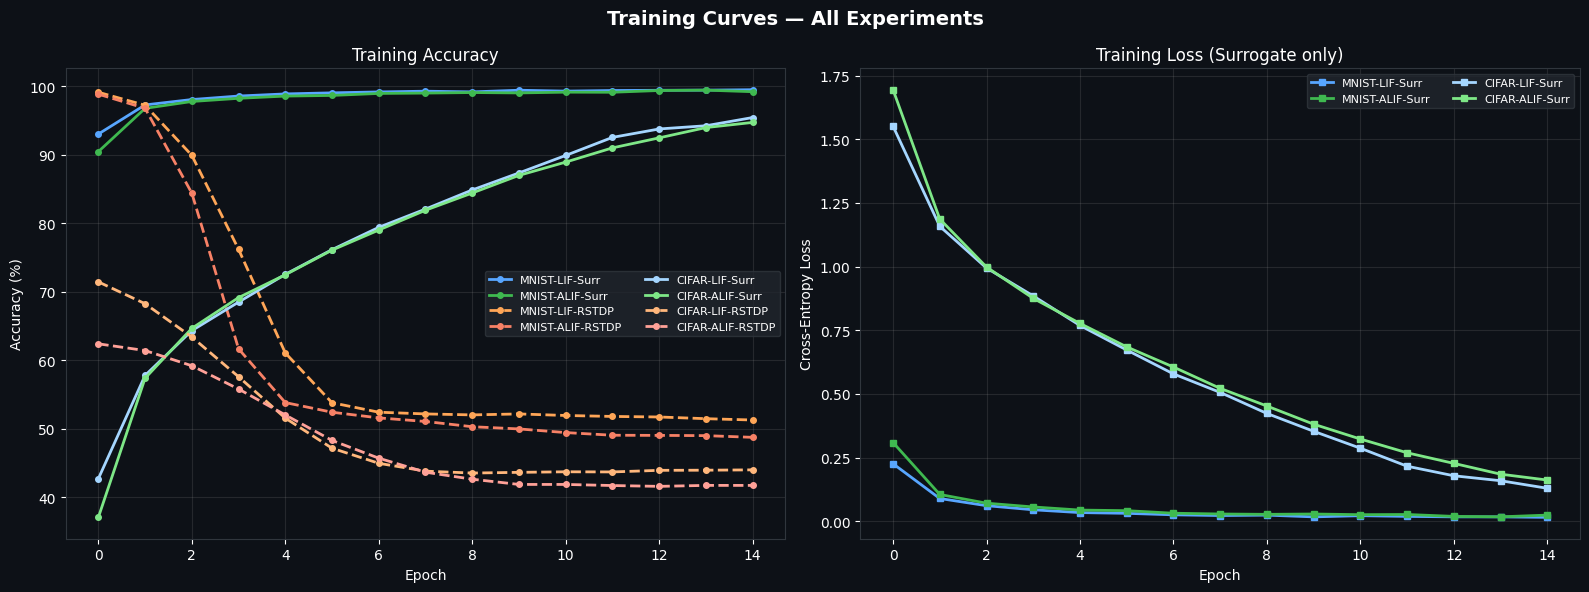

In [ ]:
# ── Research Visualization 4: Training curves ──
colors = {
    'MNIST-LIF-Surr':   '#58a6ff',
    'MNIST-ALIF-Surr':  '#3fb950',
    'MNIST-LIF-RSTDP':  '#ffa657',
    'MNIST-ALIF-RSTDP': '#f78166',
    'CIFAR-LIF-Surr':   '#a5d6ff',
    'CIFAR-ALIF-Surr':  '#7ee787',
    'CIFAR-LIF-RSTDP':  '#ffb77c',
    'CIFAR-ALIF-RSTDP': '#ffa198',
}
styles = {'Surrogate': '-', 'R-STDP': '--'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='#0d1117')
fig.suptitle('Training Curves — All Experiments', color='white', fontsize=14, fontweight='bold')

for ax in axes:
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='white')
    ax.spines[:].set_color('#30363d')
    ax.grid(True, alpha=0.15)

for key, val in results.items():
    c = colors.get(key, 'gray')
    ls = styles.get(val['strategy'], '-')
    if val.get('train_acc'):
        axes[0].plot(val['train_acc'], color=c, linestyle=ls, lw=2, label=key, marker='o', markersize=4)
    if val.get('train_loss') and any(v is not None for v in val['train_loss']):
        axes[1].plot([v for v in val['train_loss'] if v is not None],
                     color=c, linestyle=ls, lw=2, label=key, marker='s', markersize=4)

axes[0].set_title('Training Accuracy', color='white', fontsize=12)
axes[0].set_xlabel('Epoch', color='white')
axes[0].set_ylabel('Accuracy (%)', color='white')
axes[0].legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='white', fontsize=8, ncol=2)

axes[1].set_title('Training Loss (Surrogate only)', color='white', fontsize=12)
axes[1].set_xlabel('Epoch', color='white')
axes[1].set_ylabel('Cross-Entropy Loss', color='white')
axes[1].legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='white', fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig('experiment_results/training_curves.png', dpi=200, bbox_inches='tight', facecolor='#0d1117')
plt.show()

### 10.2 Final Test Accuracy — Grouped Comparison

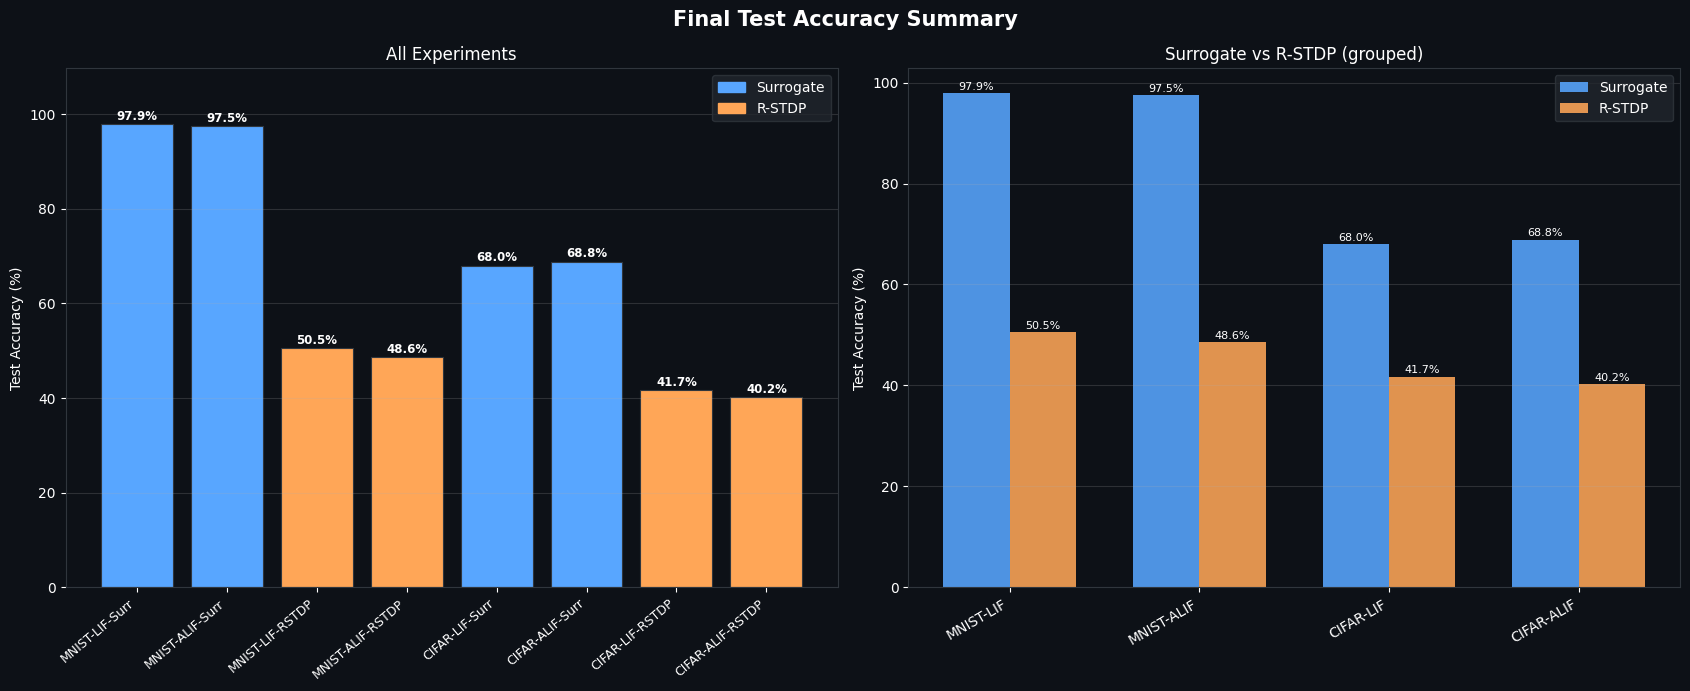

In [ ]:
# ── Research Visualization 5: Grouped bar chart ──
labels = list(results.keys())
accuracies = [results[k]['test_acc'] for k in labels]
strategies = [results[k]['strategy'] for k in labels]
datasets   = [results[k]['dataset']  for k in labels]

bar_colors = ['#58a6ff' if s == 'Surrogate' else '#ffa657' for s in strategies]
edge_colors = ['#ffffff88'] * len(labels)

fig, axes = plt.subplots(1, 2, figsize=(17, 7), facecolor='#0d1117')
fig.suptitle('Final Test Accuracy Summary', color='white', fontsize=15, fontweight='bold')

# All experiments
ax1 = axes[0]
ax1.set_facecolor('#0d1117')
bars = ax1.bar(range(len(labels)), accuracies, color=bar_colors, edgecolor='#30363d', linewidth=0.8)
for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{acc:.1f}%', ha='center', va='bottom', color='white', fontsize=8.5, fontweight='bold')
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, rotation=40, ha='right', fontsize=9, color='white')
ax1.set_ylabel('Test Accuracy (%)', color='white')
ax1.set_title('All Experiments', color='white', fontsize=12)
ax1.tick_params(colors='white')
ax1.spines[:].set_color('#30363d')
ax1.grid(axis='y', alpha=0.2)
ax1.set_ylim(0, max(accuracies) * 1.12 if accuracies else 100)
patches = [mpatches.Patch(color='#58a6ff', label='Surrogate'),
           mpatches.Patch(color='#ffa657', label='R-STDP')]
ax1.legend(handles=patches, facecolor='#21262d', edgecolor='#30363d', labelcolor='white')

# Grouped by model+dataset: Surrogate vs R-STDP
ax2 = axes[1]
ax2.set_facecolor('#0d1117')
groups = {}
for key, val in results.items():
    g = "-".join(key.split("-")[:2])
    groups.setdefault(g, {})[val['strategy']] = val['test_acc']

group_names = list(groups.keys())
surr_vals = [groups[g].get('Surrogate', 0) for g in group_names]
rstdp_vals= [groups[g].get('R-STDP',    0) for g in group_names]
x = np.arange(len(group_names))
w = 0.35

b1 = ax2.bar(x - w/2, surr_vals,  w, label='Surrogate', color='#58a6ff', alpha=0.88)
b2 = ax2.bar(x + w/2, rstdp_vals, w, label='R-STDP',    color='#ffa657', alpha=0.88)
for bar, v in [(bar, v) for bars, vals in [(b1, surr_vals),(b2, rstdp_vals)] for bar, v in zip(bars, vals)]:
    if v > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{v:.1f}%',
                 ha='center', va='bottom', color='white', fontsize=8)
ax2.set_xticks(x)
ax2.set_xticklabels(group_names, rotation=30, ha='right', color='white', fontsize=10)
ax2.set_ylabel('Test Accuracy (%)', color='white')
ax2.set_title('Surrogate vs R-STDP (grouped)', color='white', fontsize=12)
ax2.tick_params(colors='white')
ax2.spines[:].set_color('#30363d')
ax2.grid(axis='y', alpha=0.2)
ax2.legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='white')

plt.tight_layout()
plt.savefig('experiment_results/final_accuracy.png', dpi=200, bbox_inches='tight', facecolor='#0d1117')
plt.show()

### 10.3 Training Time & Efficiency Analysis

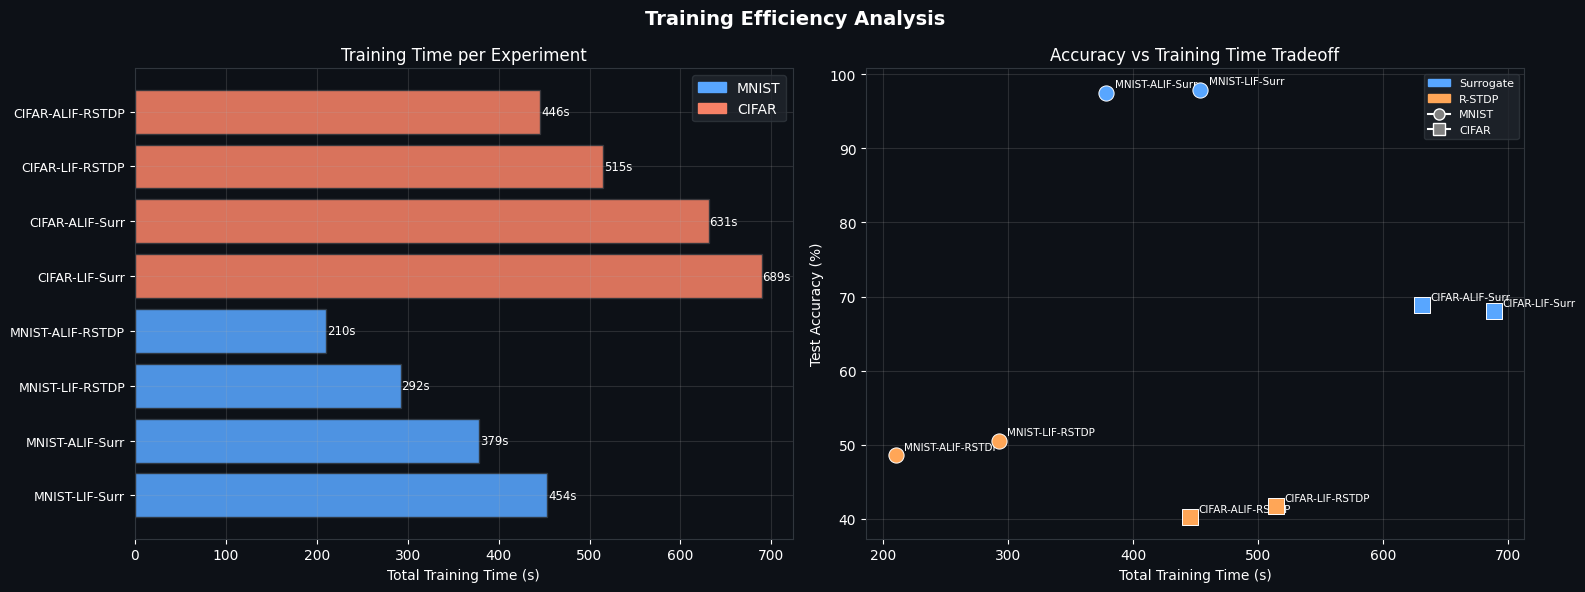

In [ ]:
# ── Research Visualization 6: Training time + accuracy/time tradeoff ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='#0d1117')
fig.suptitle('Training Efficiency Analysis', color='white', fontsize=14, fontweight='bold')

for ax in axes:
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='white')
    ax.spines[:].set_color('#30363d')
    ax.grid(True, alpha=0.18)

labels = list(results.keys())
total_times = [sum(results[k]['train_time']) for k in labels]
test_accs   = [results[k]['test_acc'] for k in labels]
dset_colors = ['#58a6ff' if results[k]['dataset'] == 'MNIST' else '#f78166' for k in labels]

axes[0].barh(range(len(labels)), total_times, color=dset_colors, edgecolor='#30363d', alpha=0.88)
axes[0].set_yticks(range(len(labels)))
axes[0].set_yticklabels(labels, color='white', fontsize=9)
axes[0].set_xlabel('Total Training Time (s)', color='white')
axes[0].set_title('Training Time per Experiment', color='white', fontsize=12)
for i, t in enumerate(total_times):
    axes[0].text(t + 1, i, f'{t:.0f}s', va='center', color='white', fontsize=8.5)
patches = [mpatches.Patch(color='#58a6ff', label='MNIST'),
           mpatches.Patch(color='#f78166', label='CIFAR')]
axes[0].legend(handles=patches, facecolor='#21262d', edgecolor='#30363d', labelcolor='white')

# Accuracy vs Time scatter
sc_colors = ['#58a6ff' if results[k]['strategy'] == 'Surrogate' else '#ffa657' for k in labels]
sc_markers = ['o' if results[k]['dataset'] == 'MNIST' else 's' for k in labels]
for i, (x_t, y_a, c, m, lbl) in enumerate(zip(total_times, test_accs, sc_colors, sc_markers, labels)):
    axes[1].scatter(x_t, y_a, color=c, marker=m, s=120, zorder=4, edgecolors='white', lw=0.7)
    axes[1].annotate(lbl, (x_t, y_a), textcoords='offset points', xytext=(6, 4),
                     color='white', fontsize=7.5)

axes[1].set_xlabel('Total Training Time (s)', color='white')
axes[1].set_ylabel('Test Accuracy (%)', color='white')
axes[1].set_title('Accuracy vs Training Time Tradeoff', color='white', fontsize=12)
legend_elems = [
    mpatches.Patch(color='#58a6ff', label='Surrogate'),
    mpatches.Patch(color='#ffa657', label='R-STDP'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='gray', ms=8, label='MNIST'),
    plt.Line2D([0],[0], marker='s', color='w', markerfacecolor='gray', ms=8, label='CIFAR'),
]
axes[1].legend(handles=legend_elems, facecolor='#21262d', edgecolor='#30363d', labelcolor='white', fontsize=8)

plt.tight_layout()
plt.savefig('experiment_results/efficiency_analysis.png', dpi=200, bbox_inches='tight', facecolor='#0d1117')
plt.show()

### 10.4 Confusion Matrix — Best Model

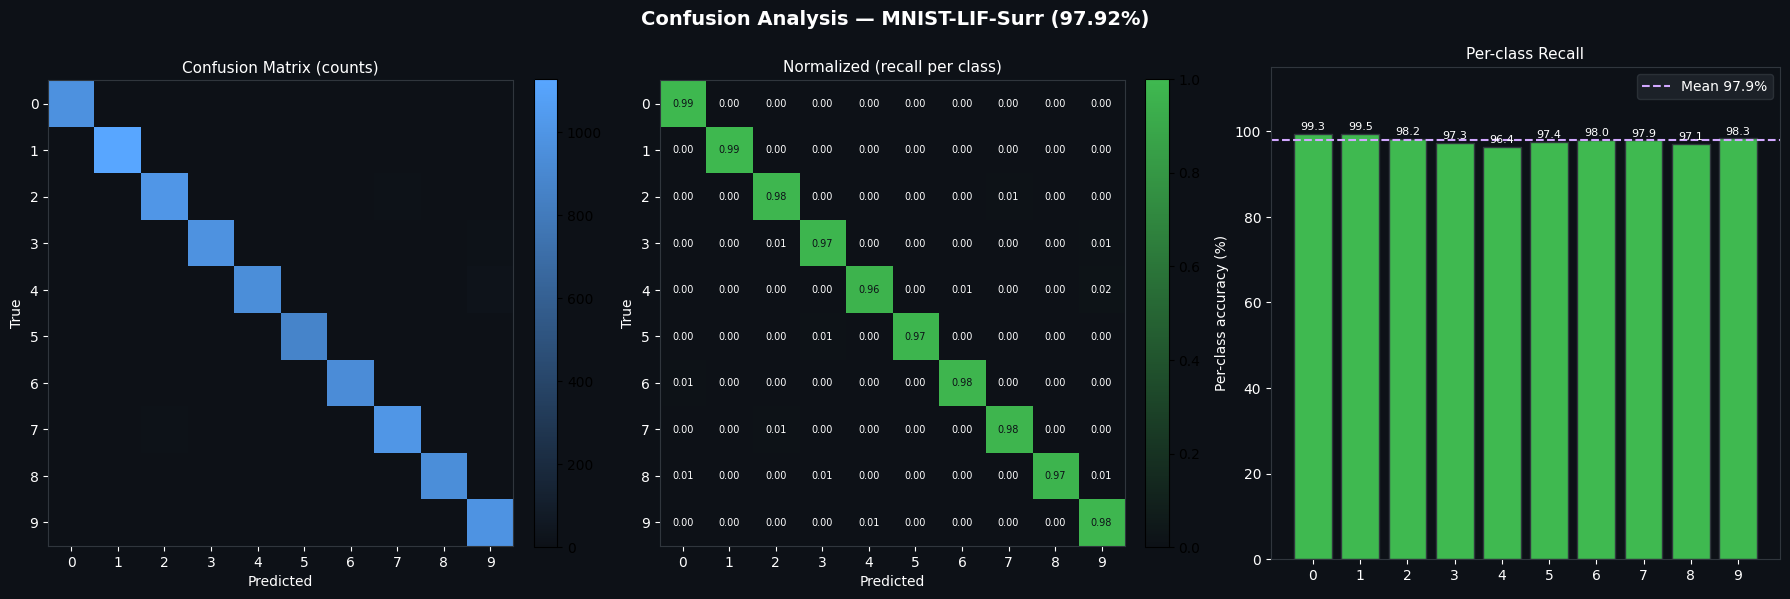

In [ ]:
# ── Research Visualization 7: Confusion matrix with per-class precision/recall ──
if best_result is not None and best_model is not None:
    cm_loader = mnist_test if best_result['dataset'] == 'MNIST' else cifar_test
    if cm_loader:
        cm = build_confusion_matrix(best_model, cm_loader, best_result['encoding'],
                                    backbone=best_result['backbone'])
        class_names = [str(i) for i in range(10)]
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

        fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='#0d1117')
        fig.suptitle(f'Confusion Analysis — {best_experiment} ({best_result["test_acc"]:.2f}%)',
                     color='white', fontsize=14, fontweight='bold')

        # Raw confusion matrix
        cmap1 = LinearSegmentedColormap.from_list('snn', ['#0d1117', '#58a6ff'])
        im1 = axes[0].imshow(cm, interpolation='nearest', cmap=cmap1)
        axes[0].set_title('Confusion Matrix (counts)', color='white', fontsize=11)
        plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
        axes[0].set_xticks(range(10)); axes[0].set_yticks(range(10))
        axes[0].set_xticklabels(class_names, color='white')
        axes[0].set_yticklabels(class_names, color='white')
        axes[0].set_xlabel('Predicted', color='white')
        axes[0].set_ylabel('True', color='white')

        # Normalized confusion matrix
        cmap2 = LinearSegmentedColormap.from_list('snn2', ['#0d1117', '#3fb950'])
        im2 = axes[1].imshow(cm_norm, interpolation='nearest', cmap=cmap2, vmin=0, vmax=1)
        for i in range(10):
            for j in range(10):
                val = cm_norm[i, j]
                axes[1].text(j, i, f'{val:.2f}', ha='center', va='center',
                             color='white' if val < 0.6 else '#0d1117', fontsize=7)
        axes[1].set_title('Normalized (recall per class)', color='white', fontsize=11)
        plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
        axes[1].set_xticks(range(10)); axes[1].set_yticks(range(10))
        axes[1].set_xticklabels(class_names, color='white')
        axes[1].set_yticklabels(class_names, color='white')
        axes[1].set_xlabel('Predicted', color='white')
        axes[1].set_ylabel('True', color='white')

        # Per-class accuracy bar chart
        per_class_acc = np.diag(cm_norm) * 100
        bar_c = ['#3fb950' if a >= 90 else ('#ffa657' if a >= 75 else '#f78166') for a in per_class_acc]
        axes[2].bar(range(10), per_class_acc, color=bar_c, edgecolor='#30363d')
        axes[2].axhline(np.mean(per_class_acc), color='#d2a8ff', linestyle='--', lw=1.5,
                        label=f'Mean {np.mean(per_class_acc):.1f}%')
        for i, a in enumerate(per_class_acc):
            axes[2].text(i, a + 0.5, f'{a:.1f}', ha='center', va='bottom', color='white', fontsize=8)
        axes[2].set_xticks(range(10))
        axes[2].set_xticklabels(class_names, color='white')
        axes[2].set_ylabel('Per-class accuracy (%)', color='white')
        axes[2].set_title('Per-class Recall', color='white', fontsize=11)
        axes[2].set_ylim(0, 115)
        axes[2].legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='white')
        for ax in axes:
            ax.set_facecolor('#0d1117')
            ax.tick_params(colors='white')
            ax.spines[:].set_color('#30363d')

        plt.tight_layout()
        plt.savefig('experiment_results/confusion_matrix.png', dpi=200, bbox_inches='tight', facecolor='#0d1117')
        plt.show()

## 11. Results Summary Table

In [ ]:
print("\n" + "="*75)
print(f"{'Experiment':<22} {'Strategy':<12} {'Dataset':<8} {'Test Acc':>10} {'Total Time':>12}")
print("="*75)
for key, val in sorted(results.items(), key=lambda x: -x[1]['test_acc']):
    t = sum(val['train_time'])
    marker = " <-- BEST" if key == best_experiment else ""
    print(f"{key:<22} {val['strategy']:<12} {val['dataset']:<8} {val['test_acc']:>9.2f}% {t:>10.1f}s{marker}")
print("="*75)
print(f"\n Neuron count per model: 256 (hidden) + 10 (output) = 266")
print(f" Total SNN neurons across all {len(results)} experiments: {266 * len(results):,}")


Experiment             Strategy     Dataset    Test Acc   Total Time
MNIST-LIF-Surr         Surrogate    MNIST        97.92%      453.8s <-- BEST
MNIST-ALIF-Surr        Surrogate    MNIST        97.49%      378.5s
CIFAR-ALIF-Surr        Surrogate    CIFAR        68.85%      631.0s
CIFAR-LIF-Surr         Surrogate    CIFAR        68.00%      689.1s
MNIST-LIF-RSTDP        R-STDP       MNIST        50.50%      292.3s
MNIST-ALIF-RSTDP       R-STDP       MNIST        48.59%      210.1s
CIFAR-LIF-RSTDP        R-STDP       CIFAR        41.68%      514.8s
CIFAR-ALIF-RSTDP       R-STDP       CIFAR        40.20%      445.6s

 Neuron count per model: 256 (hidden) + 10 (output) = 266
 Total SNN neurons across all 8 experiments: 2,128
